In [3]:
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import pandas as pd
from snewpy.models.ccsn import Nakazato_2013, Bollig_2016
from snewpy.neutrino import Flavor, MassHierarchy
from snewpy.flavor_transformation import NoTransformation, AdiabaticMSW
import uproot
from scipy.stats import gaussian_kde

/Users/jacob/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## SemiAnalytical vs Geant4 Total Photon Timing - Added by Codex

This makes one comparison plot: total detected/saved photons as a function of absolute photon arrival time. It intentionally does not break the semi-analytical result down by optical channel.


In [ ]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import uproot
import awkward as ak

repo_root = Path.cwd()
if repo_root.name == "output":
    repo_root = repo_root.parent

g4_path = repo_root / "output" / "Bollig_100_NO_events.root"
sa_path = repo_root / "output" / "Bollig_100_NO_events_SemiAnalytical.root"

for path in (g4_path, sa_path):
    if not path.exists():
        raise FileNotFoundError(path)

print("Geant4 file:", g4_path)
print("SemiAnalytical file:", sa_path)


In [ ]:
def flatten_g4_photon_times_ns(path):
    with uproot.open(path) as root_file:
        tree = root_file["G4_Photons"]
        times = tree["photon_hit_t"].array(library="ak")
    return np.asarray(ak.to_numpy(ak.flatten(times, axis=None)), dtype=np.float64)


def flatten_saved_photon_times_ns(path):
    with uproot.open(path) as root_file:
        tree = root_file["Photons"]
        saved = tree["SavedPhotons"].array(library="ak")
        detected = tree["DetectedPhotons"].array(library="np")
        generated = tree["GeneratedPhotons"].array(library="np")

    times = np.asarray(ak.to_numpy(ak.flatten(saved, axis=None)), dtype=np.float64)
    return times, detected, generated


g4_times_ns = flatten_g4_photon_times_ns(g4_path)
sa_times_ns, sa_detected, sa_generated = flatten_saved_photon_times_ns(sa_path)

print(f"Geant4 photon_hit_t total: {len(g4_times_ns):,}")
print(f"SemiAnalytical SavedPhotons total: {len(sa_times_ns):,}")
print(f"SemiAnalytical DetectedPhotons total: {int(np.sum(sa_detected)):,}")
print(f"SemiAnalytical GeneratedPhotons total: {int(np.sum(sa_generated)):,}")
print(f"SavedPhotons / Geant4 photon_hit_t: {len(sa_times_ns) / len(g4_times_ns):.4f}")


In [ ]:
time_bin_s = 1e-4  # 100 us
bin_width_ns = time_bin_s * 1e9

t_min_ns = min(np.min(g4_times_ns), np.min(sa_times_ns))
t_max_ns = max(np.max(g4_times_ns), np.max(sa_times_ns))
bins_ns = np.arange(
    np.floor(t_min_ns / bin_width_ns) * bin_width_ns,
    np.ceil(t_max_ns / bin_width_ns) * bin_width_ns + bin_width_ns,
    bin_width_ns,
)

g4_counts, edges_ns = np.histogram(g4_times_ns, bins=bins_ns)
sa_counts, _ = np.histogram(sa_times_ns, bins=bins_ns)
centers_s = 0.5 * (edges_ns[:-1] + edges_ns[1:]) * 1e-9

fig, ax = plt.subplots(figsize=(11, 5))
ax.step(
    centers_s,
    g4_counts,
    where="mid",
    lw=1.4,
    label=f"Geant4 G4_Photons, total={len(g4_times_ns):,}",
)
ax.step(
    centers_s,
    sa_counts,
    where="mid",
    lw=1.4,
    label=f"SemiAnalytical SavedPhotons, total={len(sa_times_ns):,}",
)

ax.set_yscale("log")
ax.set_xlabel("Photon arrival time [s]")
ax.set_ylabel(f"Photons per {time_bin_s * 1e6:.0f} us")
ax.set_title("Total saved/detected photons vs time")
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()


In [ ]:
# Diagnostic: where are the Geant4 optical detections happening?
with uproot.open(g4_path) as root_file:
    tree = root_file["G4_Photons"]
    g4_hit_x_cm = np.asarray(ak.to_numpy(ak.flatten(tree["photon_hit_x"].array(library="ak"), axis=None)), dtype=np.float64)
    g4_hit_y_cm = np.asarray(ak.to_numpy(ak.flatten(tree["photon_hit_y"].array(library="ak"), axis=None)), dtype=np.float64)
    g4_hit_z_cm = np.asarray(ak.to_numpy(ak.flatten(tree["photon_hit_z"].array(library="ak"), axis=None)), dtype=np.float64)

print(f"G4 detected photon positions: {len(g4_hit_z_cm):,} photons")
print(f"x range [cm]: {g4_hit_x_cm.min():.3f} to {g4_hit_x_cm.max():.3f}")
print(f"y range [cm]: {g4_hit_y_cm.min():.3f} to {g4_hit_y_cm.max():.3f}")
print(f"z range [cm]: {g4_hit_z_cm.min():.3f} to {g4_hit_z_cm.max():.3f}")

# HD geometry expectation from DetectorConstruction.cpp:
# detector z spans 0..360 cm in world coordinates; slab center is at 180 + 162.5 cm.
expected_slab_center_z_cm = 342.5
expected_slab_half_thickness_cm = 0.75
expected_slab_z_min = expected_slab_center_z_cm - expected_slab_half_thickness_cm
expected_slab_z_max = expected_slab_center_z_cm + expected_slab_half_thickness_cm

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, values, label in zip(
    axes,
    [g4_hit_x_cm, g4_hit_y_cm, g4_hit_z_cm],
    ["x [cm]", "y [cm]", "z [cm]"],
):
    ax.hist(values, bins=120, histtype="step", lw=1.5)
    ax.set_xlabel(label)
    ax.set_ylabel("Detected photons")
    ax.set_yscale("log")
    ax.grid(alpha=0.25)

axes[2].axvspan(
    expected_slab_z_min,
    expected_slab_z_max,
    color="tab:orange",
    alpha=0.25,
    label="expected silicon slab thickness",
)
axes[2].axvline(expected_slab_center_z_cm, color="tab:orange", ls="--", lw=1)
axes[2].legend()
fig.suptitle("Geant4 detected photon position distributions")
plt.tight_layout()
plt.show()


### Why the aggregate counts differ so much

The semi-analytical file is internally consistent: the total length of `SavedPhotons` matches `DetectedPhotons`. The large difference is therefore not from losing photons while writing `SavedPhotons`; it is a difference in what the two implementations define as a detected photon.

The Geant4 file records a hit whenever the optical boundary process reports `Detection` (`src/SteppingAction.cpp`). In this geometry, the `PerfectDetector` surface has `EFFICIENCY = 1`, and the skin surface is attached to `detector_logic_vol` in `src/DetectorConstruction.cpp`, not just to `Photon_detector_logic_vol`. That can make Geant4 count detections over the full LAr detector boundary.

The semi-analytical code instead computes geometric visibility for the configured optical channels and Poisson-samples detected photons from `visibility * generated_photons` (`QPixSemiAnalytical/SemiAnalyticalModel.cc`). That is a much narrower optical-channel acceptance model.


In [9]:
supernova_paths = [
    # "/Volumes/aSeVertical/SuperNova Simulation/ROOT Files/SuperNova_Models/Fornax_Normal_Hierarchy_1000_events.root",
    # "/media/iakovos-qpix/aSeVertical/SuperNova Simulation/ROOT Files/SuperNova_Models/Fornax_Inverted_Hierarchy_1000_events.root",
    # "/Volumes/aSeVertical//aSeVertical/SuperNova Simulation/ROOT Files/SuperNova_Models/Sukhbold_Normal_Hierarchy_1000_events.root",
    # "/media/iakovos-qpix/aSeVertical/SuperNova Simulation/ROOT Files/SuperNova_Models/Sukhbold_Inverted_Hierarchy_1000_events.root",
    # "/Volumes/aSeVertical/SuperNova Simulation/ROOT Files/SuperNova_Models/Nakazato_Normal_Hierarchy_1000_events.root",
    # "/Volumes/aSeVertical/SuperNova Simulation/ROOT Files/SuperNova_Models/Nakazato_Inverted_Hierarchy_1000_events.root",
    # "/Volumes/aSeVertical/SuperNova Simulation/ROOT Files/SuperNova_Models/Bollig_Normal_Hierarchy_1000_events.root",
    # "/Volumes/aSeVertical/SuperNova Simulation/ROOT Files/SuperNova_Models/Bollig_Inverted_Hierarchy_1000_events.root",
    "/Users/jacob/Programs/Library/SuperNova-Work/output/Bollig_100_NO_events.root",
]

# Labels for legend
labels = [
    # "Normal Hierarchy - Fornax Model",
    # "Normal Hierarchy - Sukhbold Model",
    "Normal Hierarchy - Bollig Model",
    # "Inverted Hierarchy - Bollig Model",
]

# Colors for each dataset
colors_supernova = [
    "#0072B2",  # blue
    "#D55E00",  # reddish orange
    "#009E73",  # bluish green
    "#CC79A7",  # reddish purple
    "#F0E442",  # yellow
    "#56B4E9",  # light blue
]

In [7]:
background_paths = [
    "/Volumes/aSeVertical/SuperNova Simulation/ROOT Files/SuperNova_Backgrounds/radiogenic_Ar39.root",
    "/Volumes/aSeVertical/SuperNova Simulation/ROOT Files/SuperNova_Backgrounds/radiogenic_Ar42.root",
    "/Volumes/aSeVertical/SuperNova Simulation/ROOT Files/SuperNova_Backgrounds/radiogenic_Pb214.root",
    "/Volumes/aSeVertical/SuperNova Simulation/ROOT Files/SuperNova_Backgrounds/radiogenic_Rn219.root"
]


labels_background = [
    "Ar39",
    "Ar42",
    "Pb214",
    "Rn219"
]

colors_background = [
    "#332288",  #  1 deep blue
    "#88CCEE",  #  2 light cyan
    "#44AA99",  #  3 teal
    "#117733",  #  4 dark green
    "#999933",  #  5 olive
    "#DDCC77",  #  6 sand
    "#CC6677",  #  7 muted red
    "#882255",  #  8 wine
    "#AA4499",  #  9 magenta
    "#DDDDDD",  # 10 light gray
    "#E69F00",  # 11 orange
    "#56B4E9",  # 12 sky blue
]

In [10]:
background_data = {}
bg_events_data = {}

for path, label in zip(background_paths, labels_background):
    file = uproot.open(path)
    tree = file["G4_Photons"]

    photon_times = tree["photon_hit_t"].array(library="np")
    
    # Flatten
    all_times = np.concatenate(photon_times)

    # Clean
    mask = (all_times > 0) & (all_times < 1e10)
    clean = all_times[mask]

    # Convert ns → s
    clean_s = clean / 1e9

    print(len(clean_s), "photons in", label)

    background_data[label] = clean_s

NameError: name 'background_paths' is not defined

In [10]:
supernova_data = {}

for path, label in zip(supernova_paths, labels):
    file = uproot.open(path)
    tree = file["G4_Photons"]

    photon_times = tree["photon_hit_t"].array(library="np")

    # Flatten
    all_times = np.concatenate(photon_times)

    # Clean
    mask = (all_times > 0) & (all_times < 1e10)
    clean = all_times[mask]

    # Convert ns → s
    clean_s = clean / 1e9

    print(len(clean_s), "photons in", label)

    supernova_data[label] = clean_s

25512964 photons in Normal Hierarchy - Bollig Model


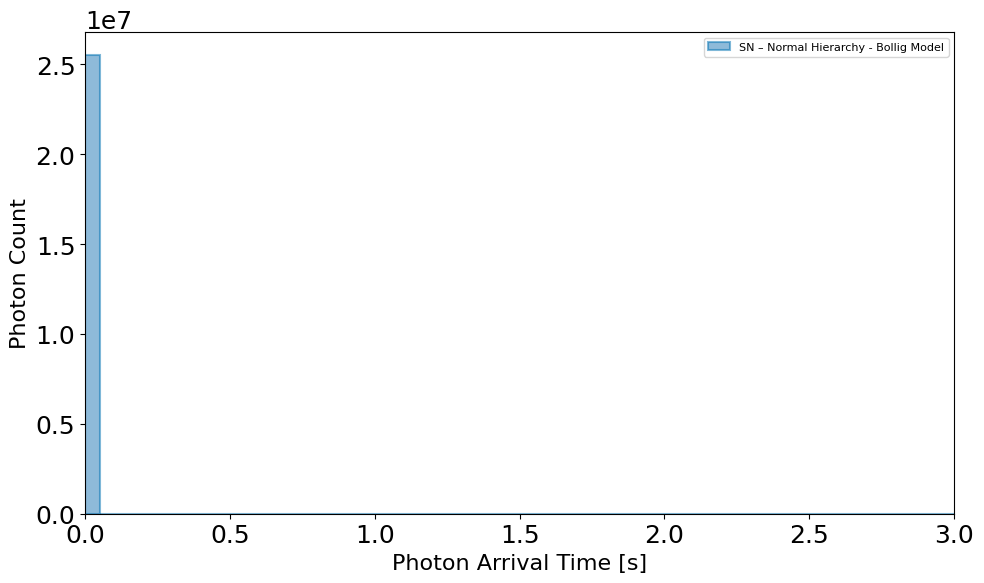

In [11]:
bin_width = 0.05
bins = np.arange(0, 3 + bin_width, bin_width)
bin_centers = 0.5 * (bins[:-1] + bins[1:])

plt.figure(figsize=(10, 6))
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 16,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 12,
    "legend.title_fontsize": 14
})

# bottom = np.zeros_like(bg_counts_list[0], dtype=float)
# for counts_bg, label_bg, color_bg in zip(bg_counts_list, labels_background, colors_background):
#     plt.bar(
#         bin_centers,
#         counts_bg,
#         width=bin_width,
#         bottom=bottom,
#         color=color_bg,
#         alpha=0.35,
#         edgecolor="black",
#         linewidth=0.7,
#         label=label_bg,
#     )
#     bottom += counts_bg

# ---- 2) All supernova models in absolute counts (lines) ----
for label_sn, color_sn in zip(labels, colors_supernova):
    data_sn = supernova_data[label_sn]
    counts_sn, _ = np.histogram(data_sn, bins=bins)
    plt.bar(
        bin_centers,
        counts_sn,
        width=bin_width,
        alpha=0.5,      # no fill
        edgecolor=color_sn,    # colored outline
        linewidth=1.5,
        label=f"SN – {label_sn}",
    )

plt.xlabel("Photon Arrival Time [s]")
plt.ylabel(f"Photon Count")
# plt.ylim(e5, 0.4e7)
plt.xlim(0,3)
plt.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

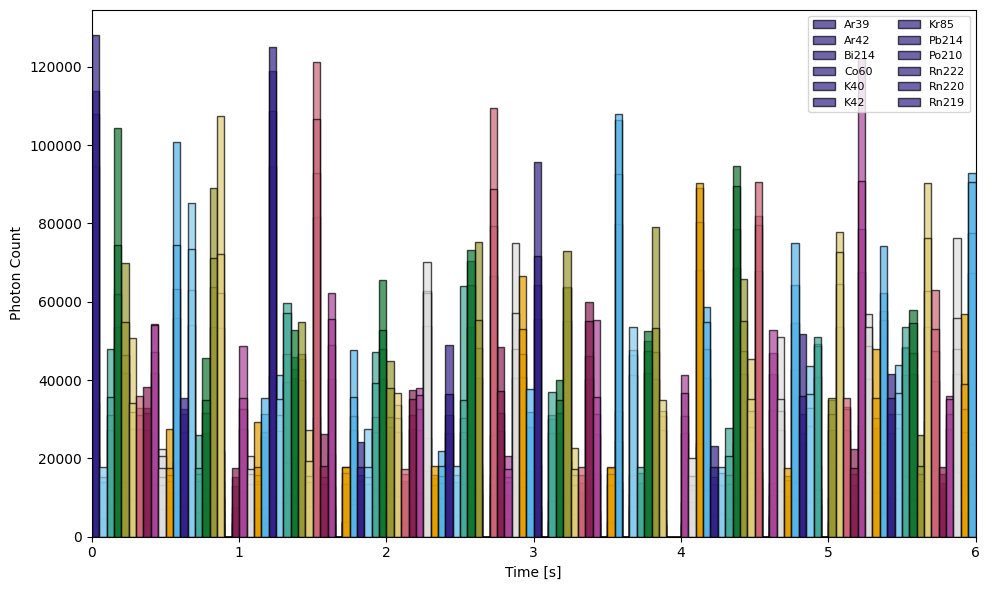

In [19]:
bin_width = 0.005
bins = np.arange(0, 3 + bin_width, bin_width)
bin_centers_bg = 0.5 * (bins[:-1] + bins[1:])


plt.figure(figsize=(10, 6))


for label_bg, color in zip(labels_background, colors_background):
    data_bg = background_data[label_bg]

    counts_bg, bin_edges  = np.histogram(data_bg, bins=bins)

    # if counts_bg.max() > 0:
    #     counts_bg_norm = counts_bg / counts_bg.max()
    # else:
    #     counts_bg_norm = counts_bg

    plt.bar(
        bin_centers_bg,
        counts_bg,
        width=bin_width,
        color=color,
        alpha=0.7,
        edgecolor="black",
        linewidth=1.0,
        label=label_bg,
    )

plt.xlabel(" Photon Arrival Time[s]")
plt.ylabel("Photon Count")
# plt.ylim(0,2e4)
# plt.yscale("log")
plt.xlim(0,3)
plt.legend(ncol=2, fontsize=8)
plt.xlim(0,3)
plt.tight_layout()
plt.show()

,peak_time_s,peak_count_per_100us,rise_t10_s,rise_t90_s,rise_10_90_us,decay_t90_s,decay_t10_s,decay_90_10_us,decay_tau_s
model,,,,,,,,,
Normal Hierarchy - Nakazato Model,0.05475,4167730.4,0.026928,0.054040,27112.702440,0.055959,0.100549,44589.466473,0.015137
Inverted Hierarchy - Nakazato Model,0.05775,3933819.0,0.024107,0.051541,27434.176228,0.058782,0.100415,41633.453963,0.018885


,delta_peak_time_s_vs_Normal Hierarchy - Nakazato Model,delta_rise_10_90_us_vs_Normal Hierarchy - Nakazato Model,delta_decay_90_10_us_vs_Normal Hierarchy - Nakazato Model,delta_decay_tau_s_vs_Normal Hierarchy - Nakazato Model
model,,,,
Normal Hierarchy - Nakazato Model,0.000,0.000000,0.00000,0.000000
Inverted Hierarchy - Nakazato Model,0.003,321.473788,-2956.01251,0.003748


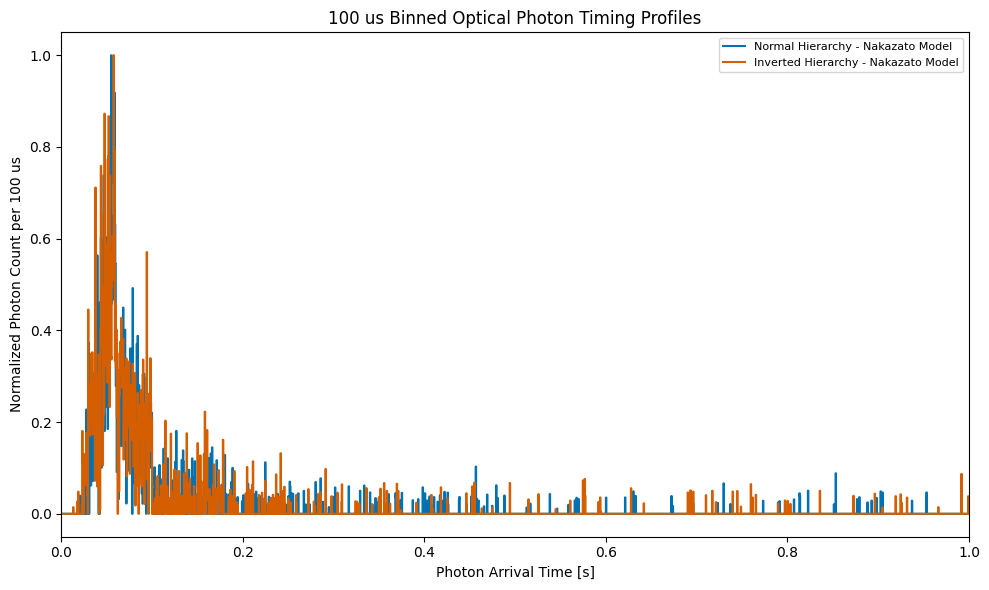

In [41]:
from scipy.optimize import curve_fit

timing_bin_width = 500e-6  # 100 us
timing_tmax = 1
timing_bins = np.arange(0, timing_tmax + timing_bin_width, timing_bin_width)
timing_centers = 0.5 * (timing_bins[:-1] + timing_bins[1:])


def _first_crossing_time(times, values, threshold, start, stop, falling=False):
    step = 1 if stop >= start else -1
    indices = range(start, stop + step, step)

    previous_index = None
    previous_value = None
    for index in indices:
        value = values[index]
        crossed = value <= threshold if falling else value >= threshold
        if crossed:
            if previous_index is None or previous_value == value:
                return times[index]
            frac = (threshold - previous_value) / (value - previous_value)
            return times[previous_index] + frac * (times[index] - times[previous_index])
        previous_index = index
        previous_value = value

    return np.nan


def _exp_decay(t, amplitude, tau, baseline):
    return baseline + amplitude * np.exp(-(t - t[0]) / tau)


def timing_metrics(photon_times, smooth_bins=5):
    counts, _ = np.histogram(photon_times, bins=timing_bins)
    profile = counts.astype(float)

    if smooth_bins > 1:
        kernel = np.ones(smooth_bins) / smooth_bins
        profile = np.convolve(profile, kernel, mode="same")

    peak_index = int(np.argmax(profile))
    peak_count = profile[peak_index]
    peak_time = timing_centers[peak_index]

    if peak_count <= 0:
        return {
            "peak_time_s": np.nan,
            "rise_t10_s": np.nan,
            "rise_t90_s": np.nan,
            "rise_10_90_us": np.nan,
            "decay_t90_s": np.nan,
            "decay_t10_s": np.nan,
            "decay_90_10_us": np.nan,
            "decay_tau_s": np.nan,
        }

    t10_level = 0.10 * peak_count
    t90_level = 0.90 * peak_count

    rise_t10 = _first_crossing_time(timing_centers, profile, t10_level, 0, peak_index)
    rise_t90 = _first_crossing_time(timing_centers, profile, t90_level, 0, peak_index)
    decay_t90 = _first_crossing_time(timing_centers, profile, t90_level, peak_index, len(profile) - 1, falling=True)
    decay_t10 = _first_crossing_time(timing_centers, profile, t10_level, peak_index, len(profile) - 1, falling=True)

    fit_mask = (timing_centers >= peak_time) & (profile > 0.05 * peak_count)
    decay_tau = np.nan
    if fit_mask.sum() >= 5:
        try:
            fit_t = timing_centers[fit_mask]
            fit_y = profile[fit_mask]
            popt, _ = curve_fit(
                _exp_decay,
                fit_t,
                fit_y,
                p0=(peak_count, 0.1, 0.0),
                bounds=([0.0, timing_bin_width, 0.0], [np.inf, timing_tmax, np.inf]),
                maxfev=10000,
            )
            decay_tau = popt[1]
        except RuntimeError:
            decay_tau = np.nan

    return {
        "peak_time_s": peak_time,
        "peak_count_per_100us": peak_count,
        "rise_t10_s": rise_t10,
        "rise_t90_s": rise_t90,
        "rise_10_90_us": (rise_t90 - rise_t10) * 1e6,
        "decay_t90_s": decay_t90,
        "decay_t10_s": decay_t10,
        "decay_90_10_us": (decay_t10 - decay_t90) * 1e6,
        "decay_tau_s": decay_tau,
    }


timing_rows = []
timing_profiles = {}

for label in labels:
    metrics = timing_metrics(supernova_data[label])
    metrics["model"] = label
    timing_rows.append(metrics)

    counts, _ = np.histogram(supernova_data[label], bins=timing_bins)
    timing_profiles[label] = counts / counts.max() if counts.max() > 0 else counts

timing_df = pd.DataFrame(timing_rows).set_index("model")
display(timing_df)

reference_model = labels[0]
comparison_columns = ["peak_time_s", "rise_10_90_us", "decay_90_10_us", "decay_tau_s"]
timing_differences = timing_df[comparison_columns].subtract(timing_df.loc[reference_model, comparison_columns])
display(timing_differences.rename(columns=lambda name: f"delta_{name}_vs_{reference_model}"))

plt.figure(figsize=(10, 6))
for label, color in zip(labels, colors_supernova):
    plt.step(timing_centers, timing_profiles[label], where="mid", color=color, label=label)

plt.xlabel("Photon Arrival Time [s]")
plt.ylabel("Normalized Photon Count per 100 us")
plt.title("100 us Binned Optical Photon Timing Profiles")
plt.xlim(0, timing_tmax)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()
